1. Load data and Understanding data:

In [12]:
import pandas as pd
import numpy as np

df = pd.read_csv("fake_antimalware_dataset.csv")

print(df.shape)          
print(df.columns.tolist())
print(df['label'].value_counts())  # 1 = malicious, 0 = benign
print(df.isnull().sum().sum())     
print(df.head())

(1199, 329)
['INTERNET', 'CLEAR\nAPP\nCACHE', 'GET\nTASKS', 'CHANGE\nWIFI\nSTATE', 'READ\nPHONE\nSTATE', 'SYSTEM\nALERT\nWINDOW', 'WRITE\nEXTERNAL\nSTORAGE', 'CALL_\nPHONE', 'CAMERA', 'READ\nCALL LOG', 'READ CONTACTS', 'WRITE CALL LOG', 'WRITE \nCONTACTS', 'READ\nHISTORY\nBOOKMARKS', 'WRITE\nHISTORY BOOKMARKS', 'ACCESS\nCOARSE\nLOCATION', 'ACCESS\nFINE\nLOCATION', 'BLUETOOTH\nADMIN', 'BLUETOOTH', 'PROCESS\nOUTGOING\nCALLS', 'BATTERY\nSTATS', 'RECORD\nAUDIO', 'DISABLE\nKEYGUARD', 'RECEIVE\nSMS', 'MANAGE\nACCOUNTS', 'AUTHENTICATE\nACCOUNTS', 'CHANGE\nWIFI\nMULTICAST\nSTATE', 'READ SMS', 'RECEIVE\nWAP\nPUSH', 'SEND SMS', 'USE\nCREDENTIALS', 'WRITE SMS', 'RECEIVE\nMMS', 'NFC', 'READ\nCALENDAR', 'WRITE\nCALENDAR', 'ACCESS\nMOCK\nLOCATION', 'SUBSCRIBED\nFEEDS\nWRITE', 'READ\nPROFILE', 'WRITE\nPROFILE', 'MOUNT\nUNMOUNT\nFILESYSTEMS', 'READ\nNETWORK\nUSAGE\nHISTORY', 'WRITE\nMEDIA\nSTORAGE', 'MODIFY\nPHONE\nSTATE', 'REBOOT', 'UPDATE\nDEVICE\nSTATS', 'PACKAGE\nUSAGE\nSTATS', 'C2D\nMESSAGE', 'WR

2. Exploratory Data Analysis (EDA):

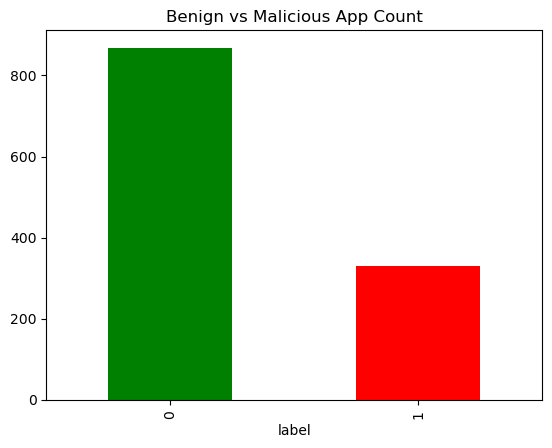

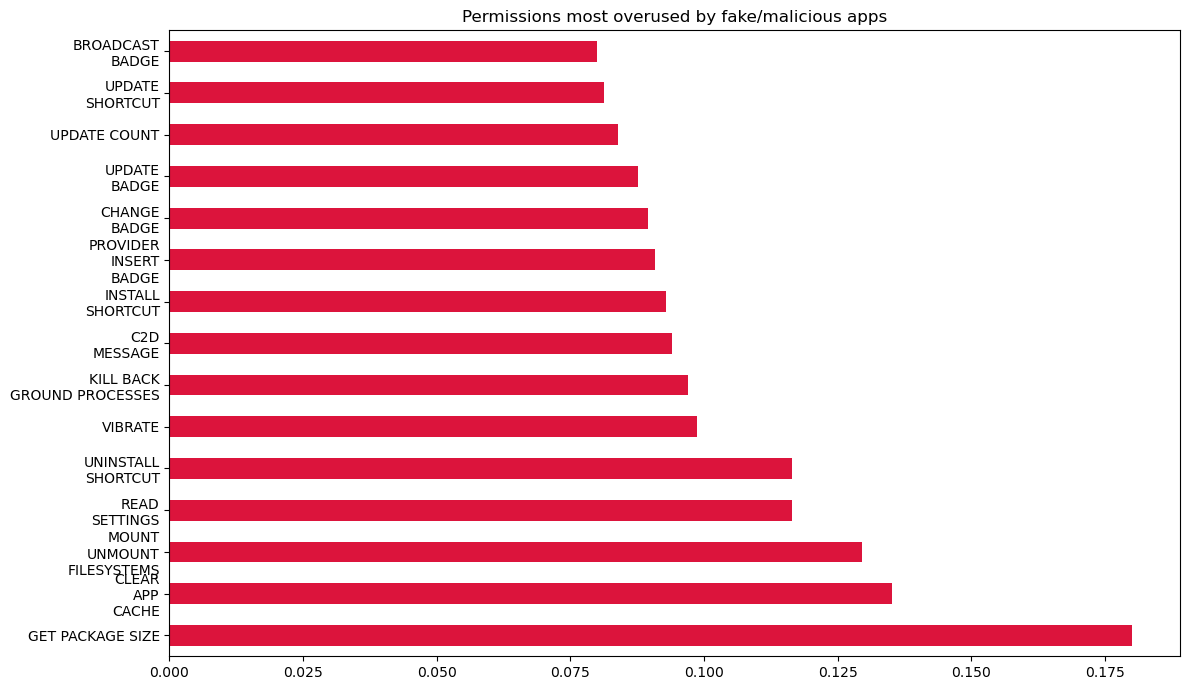

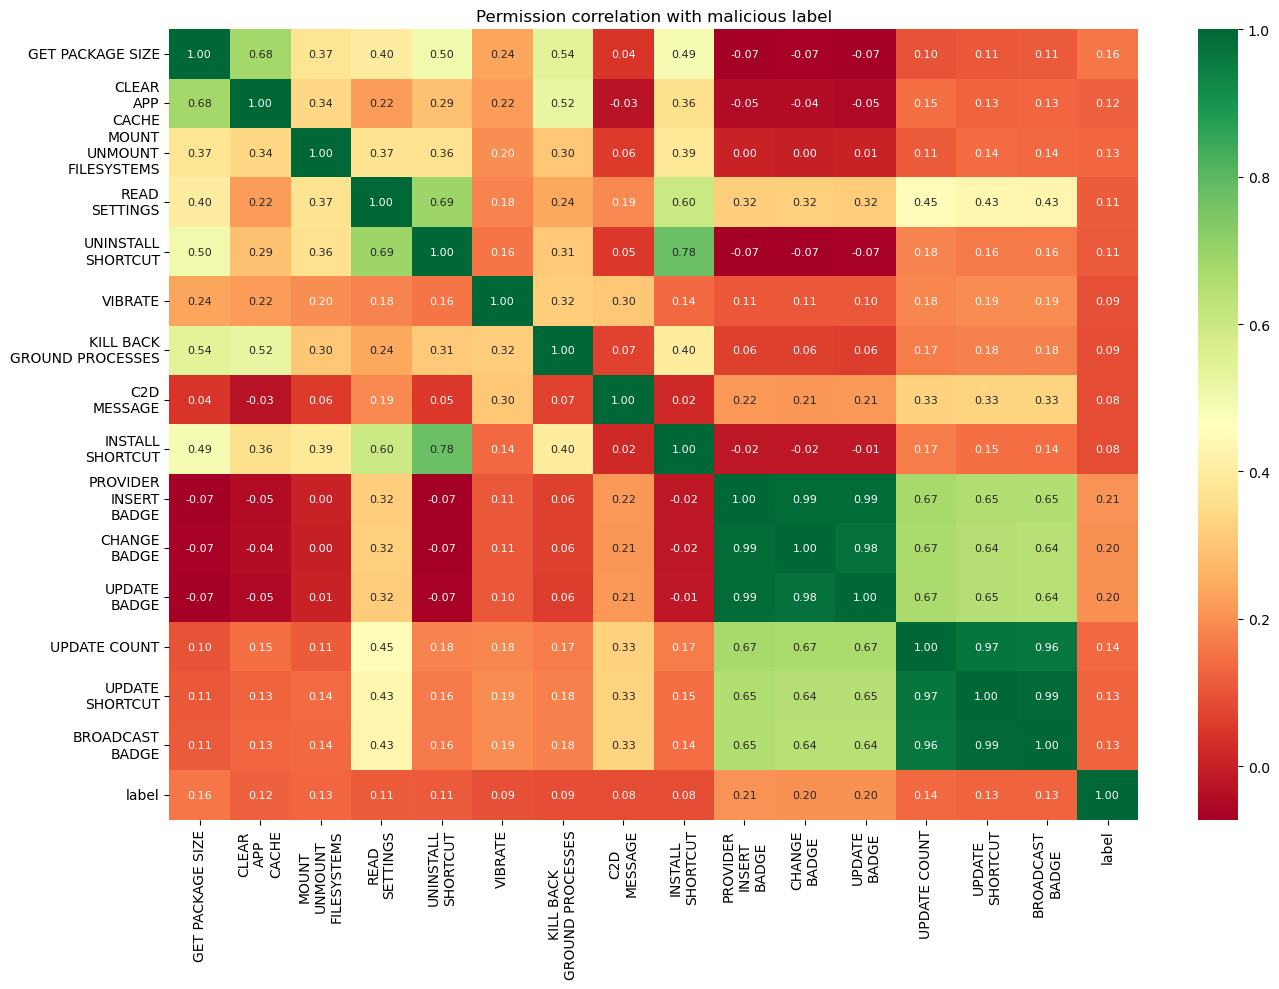

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Class balance
df['label'].value_counts().plot(kind='bar', color=['green','red'])
plt.title("Benign vs Malicious App Count")
plt.show()

# Top 15 permissions most used by malicious apps
malicious = df[df['label'] == 1].drop('label', axis=1)
benign    = df[df['label'] == 0].drop('label', axis=1)

diff = malicious.mean() - benign.mean()
top_risky = diff.sort_values(ascending=False).head(15)
top_risky.plot(kind='barh', color='crimson', figsize=(12, 7))
plt.title("Permissions most overused by fake/malicious apps")
plt.tight_layout()
plt.show()

# Correlation heatmap of top permissions
top_cols = top_risky.index.tolist() + ['label']
plt.figure(figsize=(14, 10))   
sns.heatmap(df[top_cols].corr(), annot=True, cmap='RdYlGn', fmt='.2f', annot_kws={'size': 8})
plt.title("Permission correlation with malicious label")
plt.tight_layout()
plt.show()

3 Preprocessing and Feature Selection:

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, chi2
from imblearn.over_sampling import SMOTE

X = df.drop('label', axis=1)
y = df['label']

# class imbalance with SMOTE
sm = SMOTE(random_state=42)
X_bal, y_bal = sm.fit_resample(X, y)

# Feature selection — pick top 30 most important permissions
selector = SelectKBest(chi2, k=30)
X_selected = selector.fit_transform(X_bal, y_bal)
selected_features = X.columns[selector.get_support()].tolist()
print("Top 30 selected permissions:", selected_features)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y_bal, test_size=0.2, random_state=42, stratify=y_bal
)

Top 30 selected permissions: ['CALL_\nPHONE', 'READ CONTACTS', 'ACCESS\nCOARSE\nLOCATION', 'ACCESS\nFINE\nLOCATION', 'MANAGE\nACCOUNTS', 'READ\nCALENDAR', 'WRITE\nCALENDAR', 'CHANGE\nNETWORK\nSTATE', 'ACCESS\nNOTIFICATION\nPOLICY', 'BIND GET\nINSTALL\nREFERRER\nSERVICE', 'MODIFY\nAUDIO\nSETTINGS', 'READ\nG\nSERVICES', 'BILLING', 'READ APP\nBADGE', 'CHANGE\nBADGE', 'UPDATE\nBADGE', 'PROVIDER\nINSERT\nBADGE', 'BADGE COUNT\nREAD', 'BADGE COUNT\nWRITE', 'GET\nACCOUNTS', 'READ\nSYNC\nSETTINGS', 'WRITE\nSYNC\nSETTINGS', 'FOREGROUND\nSERVICE ', 'REQUEST\nDELETE\nPACKAGES', 'REQUEST\nINSTALL\nPACKAGES', 'USE\nFINGERPRINT ', 'ACCESS\nLOCATION\nEXTRA\nCOMMANDS', 'TEMPORARY\nDISABLE', 'CHECK\nSTATUS', 'REQUEST\nIGNORE\nBATTERY\nOPTIMIZATIONS']


4. Multiple Model Building and comparison:

In [15]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score

models = {
    "Random Forest":  RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost":        XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    "MLP (paper model)": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, random_state=42),
    "SVM":            SVC(kernel='rbf', probability=True, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob) if y_prob is not None else "N/A"
    results[name] = {"Accuracy": acc, "ROC-AUC": auc}
    print(f"\n=== {name} ===")
    print(classification_report(y_test, y_pred, target_names=["Benign","Malicious"]))

# Summary table
print(pd.DataFrame(results).T)


=== Random Forest ===
              precision    recall  f1-score   support

      Benign       0.89      0.78      0.83       174
   Malicious       0.81      0.90      0.85       174

    accuracy                           0.84       348
   macro avg       0.85      0.84      0.84       348
weighted avg       0.85      0.84      0.84       348



d:\software\Lib\site-packages\xgboost\training.py:199: UserWarning: [10:30:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== XGBoost ===
              precision    recall  f1-score   support

      Benign       0.88      0.79      0.83       174
   Malicious       0.81      0.90      0.85       174

    accuracy                           0.84       348
   macro avg       0.85      0.84      0.84       348
weighted avg       0.85      0.84      0.84       348



d:\software\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(



=== MLP (paper model) ===
              precision    recall  f1-score   support

      Benign       0.90      0.78      0.84       174
   Malicious       0.81      0.91      0.86       174

    accuracy                           0.85       348
   macro avg       0.85      0.85      0.85       348
weighted avg       0.85      0.85      0.85       348


=== SVM ===
              precision    recall  f1-score   support

      Benign       0.87      0.75      0.80       174
   Malicious       0.78      0.89      0.83       174

    accuracy                           0.82       348
   macro avg       0.83      0.82      0.82       348
weighted avg       0.83      0.82      0.82       348

                   Accuracy   ROC-AUC
Random Forest      0.841954  0.899656
XGBoost            0.841954  0.888212
MLP (paper model)  0.847701  0.896766
SVM                0.818966  0.846463


5 Model Explainability (SHAP):

  0%|          | 0/50 [00:00<?, ?it/s]

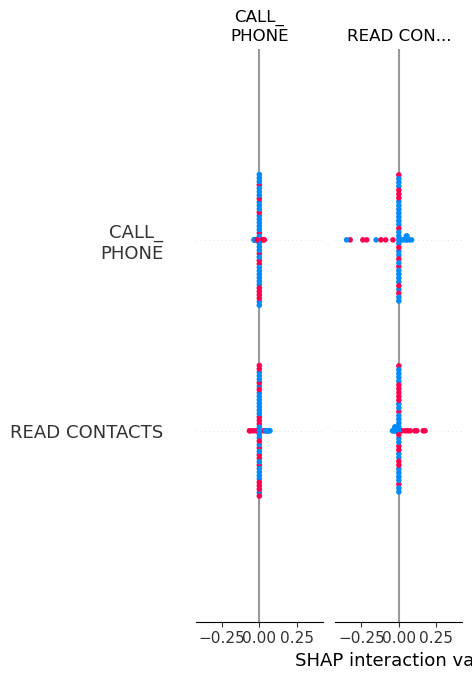

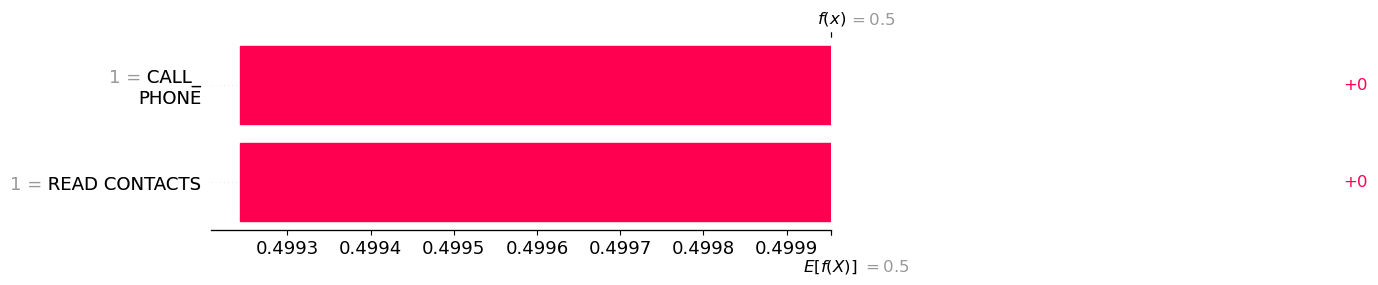

In [ ]:
import shap
import pandas as pd
import numpy as np
from xgboost import XGBClassifier

best_model = XGBClassifier(eval_metric='logloss')
best_model.fit(X_train, y_train)

X_test = pd.DataFrame(X_test, columns=selected_features)

sample_X = X_test.sample(50, random_state=42)   

explainer = shap.KernelExplainer(
    best_model.predict_proba,
    sample_X
)

shap_values = explainer.shap_values(sample_X)

shap.summary_plot(shap_values, sample_X)

shap.initjs()

import shap

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[1][0],
        base_values=explainer.expected_value[1],
        data=sample_X.iloc[0],
        feature_names=sample_X.columns
    )
)


6 Convert to Risk Score (0–100):

In [ ]:
def get_risk_score(model, features):
    features = features.values.reshape(1, -1)
    
    prob_malicious = model.predict_proba(features)[0][1]
    score = int(prob_malicious * 100)
    
    if score <= 35:
        verdict = "SAFE"
    elif score <= 70:
        verdict = "SUSPICIOUS"
    else:
        verdict = "MALICIOUS — BLOCK"
        
    return {"risk_score": score, "verdict": verdict}



sample_app = X_test.iloc[5]   
print(get_risk_score(best_model, sample_app))

{'risk_score': 49, 'verdict': 'SUSPICIOUS'}
